# 02 — Data extraction: from showers to a handful of numbers per event

Each simulated event is a full electromagnetic shower — thousands of pixel hits.
To study energy resolution we reduce every event to **five numbers** (plus a
longitudinal shower profile), then save them to one small `.npz`. That file is the training input for the ML
resolution model in [`04_resolution_ml_crystalball.ipynb`](04_resolution_ml_crystalball.ipynb);
the conventional study [`03`](03_resolution_conventional.ipynb) does **not** read it — it needs
dedicated *fixed-energy* runs (see 03's header and `analysis/extract_readouts.py`).

The reduction does two physics-motivated things:

1. **Isolates the entry module.** The photon enters one face of the 12-sided
   barrel. A shower isn't fully contained — soft secondaries leak across the
   inner air cavity and strike *other* faces. Those hits are real, but they're an
   artifact of this closed test geometry, not a property of the calorimeter
   technology. A real measurement reads out the module the beam enters, so we
   keep only hits in the **+y 30° wedge** (one of the 12 segments) at the silicon
   radius.
2. **Applies a readout threshold.** A pixel only registers if its deposit clears
   a zero-suppression threshold (~½ MIP), exactly as a real chip would.

**Kernel**: `Key4hep (CPU)` (I/O-bound).
**Output**: `$CALOMAPS_HOME/models/decal_extracted_data_<particle>.npz`.

## 0. Choose your particle

The **one knob**. Everything downstream — which dataset directory is read and which output
`.npz` is written — derives from `PARTICLE`, exactly as in notebooks
[03](03_resolution_conventional.ipynb)/[04](04_resolution_ml_crystalball.ipynb). Photons are
the default; point it at `"pi+"` to extract a pion dataset (which you must have generated
first — see [`00_simulate_your_samples.ipynb`](00_simulate_your_samples.ipynb) §5).


In [1]:
# ---- THE ONE KNOB ----
PARTICLE = "gamma"          # "gamma" or "pi+"
PART_TAG   = "gamma" if PARTICLE == "gamma" else "piplus"
FILE_TAG   = "photons" if PARTICLE == "gamma" else PART_TAG   # sim_<FILE_TAG>_part*.root
DSET_SUFFIX = "" if PARTICLE == "gamma" else f"_{PART_TAG}"   # data_spectrum_100um_400GeV[_piplus]
print(f"PARTICLE = {PARTICLE!r}  ->  dataset data_spectrum_100um_400GeV{DSET_SUFFIX}, "
      f"glob sim_{FILE_TAG}_part*.root, output decal_extracted_data_{PART_TAG}.npz")


PARTICLE = 'gamma'  ->  dataset data_spectrum_100um_400GeV, glob sim_photons_part*.root, output decal_extracted_data_gamma.npz


## 1. Parameters and detector geometry

The MIP scale (`MIP_ENERGY`) is the Landau most-probable energy deposit of a
minimum-ionizing particle in the silicon sensor. We read the 30 silicon layer
**radii** from the geometry XML so the layer assignment stays correct even inside
the tilted wedge.

In [2]:
import os, glob, xml.etree.ElementTree as ET
import numpy as np, uproot
from concurrent.futures import ProcessPoolExecutor, as_completed

# Resolve the repo root. Prefer $CALOMAPS_HOME (exported by `source setup_calomaps.sh`
# in a terminal); otherwise auto-locate it by walking up from the kernel's working
# directory, so the notebook also works when opened from the JupyterLab GUI — whose
# kernel does NOT inherit a terminal's environment.
def _calomaps_home():
    h = os.environ.get("CALOMAPS_HOME")
    if h and os.path.isdir(os.path.join(h, "geometry")):
        return h
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.isdir(os.path.join(p, "geometry")) and os.path.isdir(os.path.join(p, "sim")):
            return p
        p = os.path.dirname(p)
    return os.path.expanduser("~/CALOMAPS")
CALOMAPS_HOME = _calomaps_home()
DATA_BASE     = os.environ.get("CALOMAPS_DATA_BASE", os.path.expanduser("~/CALOMAPS-data"))
DATASET       = "data_spectrum_100um_400GeV" + DSET_SUFFIX

CELL_SIZE  = 0.1            # mm — 100 um pixel pitch
MIP_ENERGY = 85e-6          # GeV — Landau MPV for the sensor
THRESHOLD  = 0.5 * MIP_ENERGY   # zero-suppression: a pixel "fires" above 1/2 MIP
NSIDES     = 12                 # dodecagonal barrel
SEG_HALF_DEG = 180.0 / NSIDES   # 15 deg half-wedge (one segment)
RMIN, RMAX = 1264.0, 1403.0     # silicon shell inner/outer radius [mm]

def _pv(v, c):
    if not v: return 0.0
    if v in c: return _pv(c[v], c)
    s = v.replace('*', ' * ').replace('cm', '10').replace('mm', '1')
    try: return float(eval(s, {"__builtins__": None}, {}))
    except Exception:
        try: return float(v)
        except Exception: return 0.0

def layer_radii():
    g = os.path.join(CALOMAPS_HOME, "geometry")
    consts = {x.get("name"): x.get("value")
              for x in ET.parse(os.path.join(g, "SiD_TestBeam.xml")).getroot().findall(".//constant")}
    det = ET.parse(os.path.join(g, "my_custom_ecal.xml")).getroot().find(".//detector[@name='ECalBarrel']")
    cur, planes = _pv(det.find("dimensions").get("rmin"), consts), []
    for layer in det.findall("layer"):
        rep = int(layer.get("repeat", 1)); sl = layer.findall("slice")
        thick = sum(_pv(s.get("thickness"), consts) for s in sl)
        off = sioff = 0.0
        for s in sl:
            t = _pv(s.get("thickness"), consts)
            if s.get("material") == "Silicon": sioff = off + t / 2
            off += t
        for _ in range(rep):
            planes.append(cur + sioff); cur += thick
    return np.array(planes)

RADII = layer_radii()
NUM_LAYERS = len(RADII)
# energy bins for the longitudinal-profile accumulation (25 GeV wide, 0-400)
PROFILE_BINS = [(25 * i, 25 * (i + 1)) for i in range(16)]
print(f"parsed {NUM_LAYERS} silicon layers, r = [{RADII.min():.1f}, {RADII.max():.1f}] mm")

parsed 30 silicon layers, r = [1266.9, 1400.7] mm


## 2. The five numbers we keep per event

| variable | what it is | readout it models |
|---|---|---|
| `all_truth` | true photon energy `√(p²+m²)` | the label we want to recover |
| `all_visible` | Σ energy of all hits in the segment | **True Analog** (perfect charge sum) |
| `all_mip` | Σ over fired pixels of `max(1, round(E_pix/E_MIP))` (each fired pixel counts >= 1 MIP) | **MIP counting** (MIPs-per-pixel) |
| `all_hits` | number of pixels above ½-MIP threshold | **Raw Hits** (pure binary/digital) |
| `all_cluster` | number of 8-connected clusters, summed over layers | **Naive 2D Clustering** |

These form a ladder of readout sophistication. At low energy they all track the
energy linearly; at high energy the *digital* ones break down — pixels saturate
(one pixel hit by several particles still counts once), so **Hits** goes
sublinear and **Clustering** turns over as adjacent pixels merge. **Analog** and
**MIP** stay closest to linear.

We *also* accumulate the **longitudinal shower profile** — energy deposited per
silicon layer — averaged in 25 GeV truth-energy bins, to see how shower depth
grows with energy.

## 3. Per-file worker

For each event: keep hits in the +y wedge, assign each to its nearest silicon
layer by radius, compute the five numbers, and accumulate the per-layer energy
profile. Clustering uses an 8-connected flood-fill on the pixel grid (identical
to `DBSCAN(eps=1.5·pitch, min_samples=1)` but O(n)).

In [3]:
def naive_clusters(x, z, layer_idx, e):
    # 8-connected components per layer, summed.
    m = e > THRESHOLD
    if not m.any():
        return 0
    xi = np.round(x[m] / CELL_SIZE).astype(np.int64)
    zi = np.round(z[m] / CELL_SIZE).astype(np.int64)
    li = layer_idx[m]
    total = 0
    for ly in np.unique(li):
        sel = li == ly
        cells_ = set(zip(xi[sel].tolist(), zi[sel].tolist()))
        seen = set()
        for c0 in cells_:
            if c0 in seen:
                continue
            total += 1
            stack = [c0]
            while stack:
                ux, uz = stack.pop()
                if (ux, uz) in seen:
                    continue
                seen.add((ux, uz))
                for dx in (-1, 0, 1):
                    for dz in (-1, 0, 1):
                        v = (ux + dx, uz + dz)
                        if v in cells_ and v not in seen:
                            stack.append(v)
    return total

def process_single_file(filepath):
    br = ["ECalBarrelHits.position.x", "ECalBarrelHits.position.y",
          "ECalBarrelHits.position.z", "ECalBarrelHits.energy",
          "MCParticles.momentum.x", "MCParticles.momentum.y",
          "MCParticles.momentum.z", "MCParticles.mass"]
    T, V, M, H, C = [], [], [], [], []
    p_sum = np.zeros((len(PROFILE_BINS), NUM_LAYERS))   # energy per layer, per E-bin
    p_cnt = np.zeros(len(PROFILE_BINS), dtype=np.int64)
    try:
        with uproot.open(filepath) as f:
            tr = f["events"]
            if tr.num_entries == 0:
                return None
            a = tr.arrays(br)
            truth = np.sqrt(a["MCParticles.momentum.x"][:, 0]**2 +
                            a["MCParticles.momentum.y"][:, 0]**2 +
                            a["MCParticles.momentum.z"][:, 0]**2 +
                            a["MCParticles.mass"][:, 0]**2)
            hx, hy = a["ECalBarrelHits.position.x"], a["ECalBarrelHits.position.y"]
            hz, he = a["ECalBarrelHits.position.z"], a["ECalBarrelHits.energy"]
            for ev in range(len(he)):
                x = np.asarray(hx[ev]); y = np.asarray(hy[ev])
                z = np.asarray(hz[ev]); e = np.asarray(he[ev])
                if len(e) == 0:
                    continue
                ang = np.degrees(np.arctan2(x, y))           # angle from +y in x-y plane
                seg = (np.abs(ang) < SEG_HALF_DEG) & (y > RMIN - 4) & (y < RMAX + 14)
                x, z, e, y = x[seg], z[seg], e[seg], y[seg]
                if len(e) == 0:
                    continue
                layer_idx = np.argmin(np.abs(RADII[None, :] - y[:, None]), axis=1)
                thr = e > THRESHOLD
                et = float(truth[ev])
                T.append(et)
                V.append(float(e.sum()))                                       # analog
                M.append(float(np.maximum(1, np.round(e[thr] / MIP_ENERGY)).sum()))  # MIPs/pixel
                H.append(int(thr.sum()))                                        # binary hits
                C.append(naive_clusters(x, z, layer_idx, e))                    # clusters
                # longitudinal profile: total energy per layer, into its E-bin
                le = np.bincount(layer_idx, weights=e, minlength=NUM_LAYERS)[:NUM_LAYERS]
                for b, (lo, hi) in enumerate(PROFILE_BINS):
                    if lo <= et < hi:
                        p_sum[b] += le; p_cnt[b] += 1
                        break
    except Exception as ex:
        print(f"  failed {os.path.basename(filepath)}: {ex}")
        return None
    return T, V, M, H, C, p_sum, p_cnt

## 4. Run the extraction in parallel and save

Forks a process pool over the ~889 files. With the grid clustering this is
I/O-bound and finishes in well under a couple of minutes.

In [4]:
file_list = sorted(glob.glob(os.path.join(DATA_BASE, DATASET, f"sim_{FILE_TAG}_part*.root")))
print(f"Found {len(file_list)} files. Extracting...")

all_truth, all_visible, all_mip, all_hits, all_cluster = [], [], [], [], []
prof_sum = np.zeros((len(PROFILE_BINS), NUM_LAYERS))
prof_cnt = np.zeros(len(PROFILE_BINS), dtype=np.int64)
with ProcessPoolExecutor(max_workers=min(32, os.cpu_count() or 8)) as ex:
    futures = {ex.submit(process_single_file, f): f for f in file_list}
    for n, fut in enumerate(as_completed(futures), 1):
        r = fut.result()
        if r:
            all_truth += r[0]; all_visible += r[1]; all_mip += r[2]
            all_hits += r[3]; all_cluster += r[4]
            prof_sum += r[5]; prof_cnt += r[6]
        if n % 100 == 0:
            print(f"  {n}/{len(file_list)}")

all_truth   = np.array(all_truth)
all_visible = np.array(all_visible, dtype=np.float32)
all_mip     = np.array(all_mip, dtype=np.float32)
all_hits    = np.array(all_hits, dtype=np.int64)
all_cluster = np.array(all_cluster, dtype=np.int64)

out_dir = os.path.join(CALOMAPS_HOME, "models"); os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"decal_extracted_data_{PART_TAG}.npz")
np.savez_compressed(out_path, all_truth=all_truth, all_visible=all_visible,
                    all_mip=all_mip, all_hits=all_hits, all_cluster=all_cluster,
                    profile_sum=prof_sum, profile_counts=prof_cnt,
                    layer_radii=RADII, profile_bins=np.array(PROFILE_BINS))
print(f"\nExtracted {len(all_truth)} events -> {out_path} ({os.path.getsize(out_path)/1024:.0f} KB)")

Found 889 files. Extracting...


  100/889


  200/889


  300/889


  400/889


  500/889


  600/889


  700/889


  800/889



Extracted 17780 events -> /nashome/m/murtazas/CALOMAPS-rework/models/decal_extracted_data_gamma.npz (338 KB)


## 5. The raw readout distributions

Plot each readout against true energy. The dashed line is a straight fit to the
**low-energy** region (< 50 GeV), extrapolated across the full range — so any
**deviation at high energy is the digital breakdown**:

- **Analog / MIP** stay close to the line (energy- and MIP-proportional).
- **Raw Hits** droops below it — *pixel saturation*: above ~100 GeV the shower
  core puts several particles through the same 100 µm pixel, but a binary pixel
  can only say "hit once".
- **Clustering** turns over even harder — dense cores merge adjacent pixels into
  a few big blobs, so the *count* of clusters stops growing.

The vertical scatter at fixed energy is the **intrinsic resolution** of each
readout — exactly what notebooks [03](03_resolution_conventional.ipynb)
(conventional Crystal-Ball fits) and [04](04_resolution_ml_crystalball.ipynb)
(ML density) turn into σ_E/E.

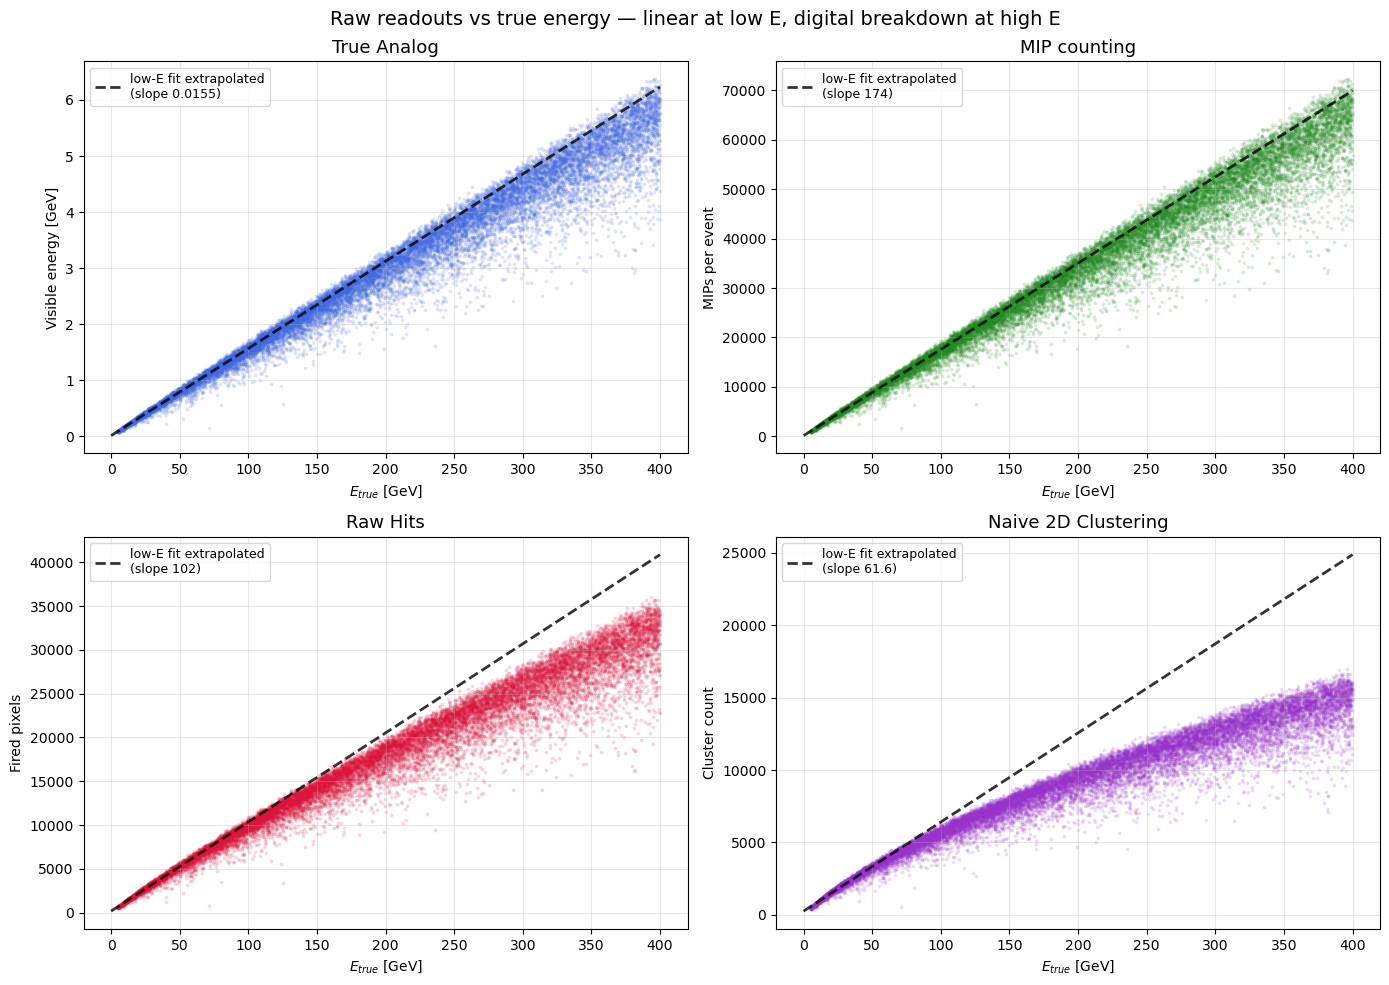

In [5]:
import matplotlib.pyplot as plt

panels = [("True Analog", all_visible, "royalblue", "Visible energy [GeV]"),
          ("MIP counting", all_mip, "forestgreen", "MIPs per event"),
          ("Raw Hits", all_hits, "crimson", "Fired pixels"),
          ("Naive 2D Clustering", all_cluster, "darkorchid", "Cluster count")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, y, col, ylab) in zip(axes.flat, panels):
    good = (all_truth > 0) & (y > 0)
    t, yy = all_truth[good], y[good].astype(float)
    ax.scatter(t, yy, s=3, alpha=0.12, color=col)
    lo = t < 50
    if lo.sum() > 10:
        m, c = np.polyfit(t[lo], yy[lo], 1)
        xl = np.array([0, t.max()])
        ax.plot(xl, m * xl + c, "k--", lw=2, alpha=0.8,
                label=f"low-E fit extrapolated\n(slope {m:.3g})")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("$E_{true}$ [GeV]"); ax.set_ylabel(ylab)
    ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Raw readouts vs true energy — linear at low E, digital breakdown at high E", fontsize=14)
plt.tight_layout()
plt.show()

## 6. The response is a distribution — "resolution" is its width

At any fixed true energy a readout doesn't give one value — it gives a spread
(shower-to-shower fluctuations). Below is the distribution of one readout in a
narrow energy slice. Its **width sets the resolution**, and it isn't necessarily
Gaussian: shower leakage pulls a low-side tail. Notebook
[03](03_resolution_conventional.ipynb) fits a Crystal-Ball function (Gaussian core
+ power-law tail) to distributions exactly like this one, and notebook
[04](04_resolution_ml_crystalball.ipynb) teaches a network to produce that same
density at every energy at once.


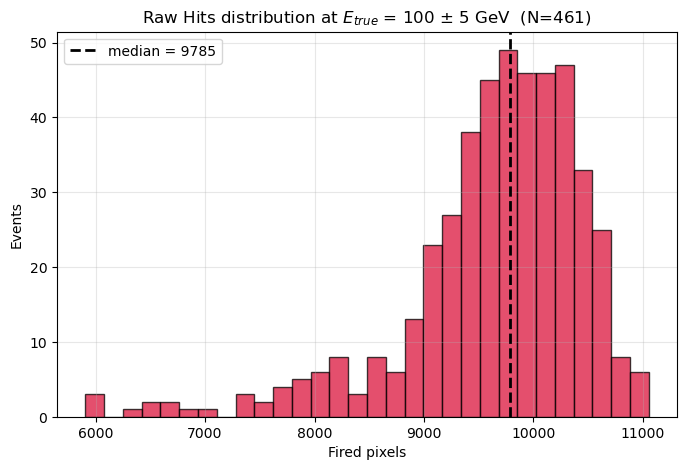

In [6]:
E0, dE = 100.0, 5.0
sl = np.abs(all_truth - E0) < dE
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_hits[sl], bins=30, color="crimson", alpha=0.75, edgecolor="black")
med = np.median(all_hits[sl])
ax.axvline(med, color="black", lw=2, ls="--", label=f"median = {med:.0f}")
ax.set_title(f"Raw Hits distribution at $E_{{true}}$ = {E0:.0f} $\\pm$ {dE:.0f} GeV  (N={sl.sum()})")
ax.set_xlabel("Fired pixels"); ax.set_ylabel("Events")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 7. Longitudinal shower profile

How deep does the shower go, and how does that change with energy? Averaging the
per-layer energy in each 25 GeV bin gives the **longitudinal shower profile**.
Higher-energy showers peak deeper and deposit more in every layer. The red line
marks where the absorber switches from thin (2.5 mm W) to thick (5.0 mm W) — the
profile compresses past it.

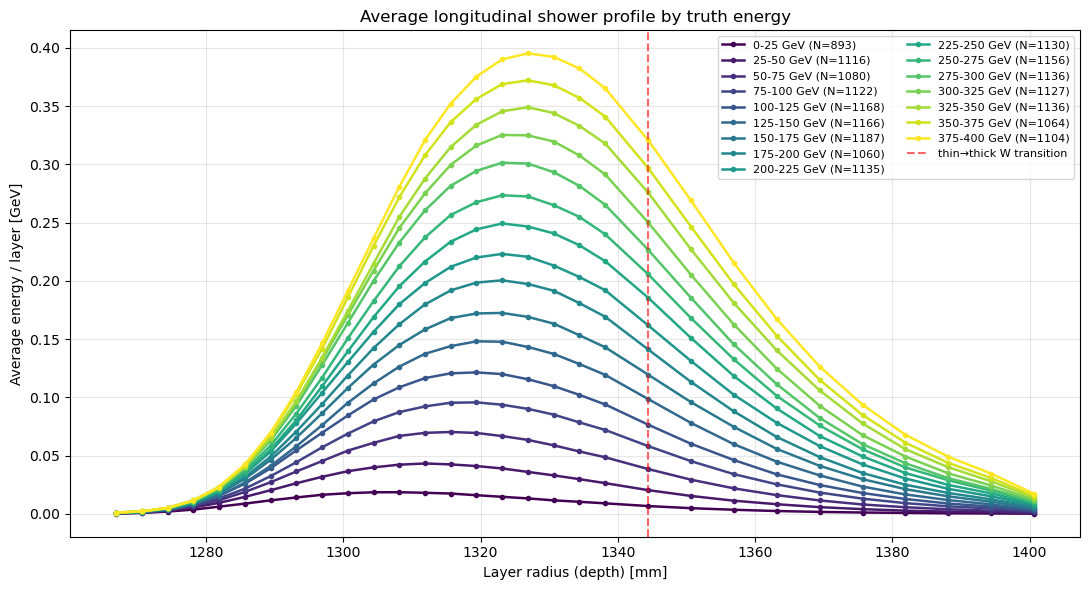

In [7]:
radii = RADII
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(PROFILE_BINS)))
for b, (lo, hi) in enumerate(PROFILE_BINS):
    if prof_cnt[b] == 0:
        continue
    avg = prof_sum[b] / prof_cnt[b]
    ax.plot(radii, avg, marker="o", ms=3, lw=1.8, color=cmap[b],
            label=f"{lo}-{hi} GeV (N={prof_cnt[b]})")
if len(radii) > 20:
    ax.axvline(radii[20], color="red", ls="--", alpha=0.6, label="thin→thick W transition")
ax.set_xlabel("Layer radius (depth) [mm]"); ax.set_ylabel("Average energy / layer [GeV]")
ax.set_title("Average longitudinal shower profile by truth energy")
ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Done. The five-number summary (+ longitudinal profile) is saved. Next:
[`04_resolution_ml_crystalball.ipynb`](04_resolution_ml_crystalball.ipynb) trains the ML
density model on **this** spectrum file (plus two low-energy anchor runs).
[`03_resolution_conventional.ipynb`](03_resolution_conventional.ipynb) measures the same
quantity a second, independent way from dedicated fixed-energy runs (not this file), and the
two are overlaid.
